In [67]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# --- KONFIGURACJA ---
REF_MASK_PATH = "reference_mask_vote_0.50.npy"
CASE_TOP_RATIO = 0.55          # Analizujemy tylko górną część obiektu
CASE_CENTER_WIDTH_RATIO = 0.62 # Dodatkowe zawężenie ROI do środka obudowy
TOP_IGNORE_RATIO = 0.30      # Zwiekszone ignorowanie górnego pasa dla redukcji FP
DARK_CASE_THRESHOLD = 60       # Bardziej restrykcyjna maska czarnego case
BRIGHTNESS_THRESHOLD = 120     # Wyższy próg jasnosci, mniej fałszywych alarmów
MIN_DAMAGE_AREA = 320          # Większe wymagane pole defektu
SAFE_EROSION_ITERATIONS = 1    # Margines od krawędzi case

# Wstepne wygladzenie dla mapy jasnosci (redukcja refleksow punktowych)
USE_BRIGHTNESS_BLUR = True
BRIGHTNESS_BLUR_TYPE = "median"   # "median" albo "gaussian"
BRIGHTNESS_BLUR_KERNEL = 3         # Musi byc nieparzyste

# Załaduj maskę referencyjną
if os.path.exists(REF_MASK_PATH):
    REFERENCE_MASK = np.load(REF_MASK_PATH).astype(np.uint8)
    if REFERENCE_MASK.max() == 1:
        REFERENCE_MASK *= 255
    print("Maska referencyjna załadowana.")
else:
    print("BŁĄD: Nie znaleziono pliku maski referencyjnej!")

Maska referencyjna załadowana.


In [55]:
def keep_largest_component(mask):
    """Zostawia tylko największą spójną składową binarnej maski."""
    bin_mask = (mask > 0).astype(np.uint8)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(bin_mask, connectivity=8)

    if num_labels <= 1:
        return (bin_mask * 255).astype(np.uint8)

    largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    largest = (labels == largest_label).astype(np.uint8) * 255
    return largest.astype(np.uint8)

def get_aligned_mask(test_mask, ref_mask):
    """Proste wyrównanie testowej maski do wzorca na podstawie środka ciężkości."""
    M_ref = cv2.moments(ref_mask)
    M_test = cv2.moments(test_mask)

    if M_ref["m00"] == 0 or M_test["m00"] == 0:
        return test_mask  # Nie można wyrównać

    dx = int(M_ref["m10"] / M_ref["m00"] - M_test["m10"] / M_test["m00"])
    dy = int(M_ref["m01"] / M_ref["m00"] - M_test["m01"] / M_test["m00"])

    rows, cols = test_mask.shape
    M = np.float32([[1, 0, dx], [0, 1, dy]])
    return cv2.warpAffine(test_mask, M, (cols, rows), flags=cv2.INTER_NEAREST)

def extract_mask(img_rgb):
    """Uproszczona ekstrakcja tranzystora."""
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    _, mask = cv2.threshold(gray, 60, 255, cv2.THRESH_BINARY_INV)
    kernel = np.ones((3, 3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    mask = keep_largest_component(mask)
    return mask

def get_case_only_mask(full_mask, top_ratio=CASE_TOP_RATIO, center_width_ratio=CASE_CENTER_WIDTH_RATIO):
    """Wycina z pełnej maski tylko górną, centralną część obudowy."""
    mask = (full_mask > 0).astype(np.uint8) * 255
    y_coords, _ = np.where(mask > 0)

    if len(y_coords) == 0:
        return mask

    y_min, y_max = y_coords.min(), y_coords.max()
    height = y_max - y_min
    case_bottom_y = y_min + int(height * top_ratio)

    case_only = np.zeros_like(mask)
    case_only[y_min:case_bottom_y, :] = mask[y_min:case_bottom_y, :]
    case_only = keep_largest_component(case_only)

    x_coords = np.where(case_only > 0)[1]
    if len(x_coords) == 0:
        return case_only

    x_min, x_max = x_coords.min(), x_coords.max()
    width = x_max - x_min + 1
    trim = int(width * (1.0 - center_width_ratio) / 2.0)
    left = x_min + trim
    right = x_max - trim

    centered = np.zeros_like(case_only)
    centered[:, left:right + 1] = case_only[:, left:right + 1]
    centered = keep_largest_component(centered)
    return centered

def get_dark_case_mask(img_rgb, case_region_mask, dark_threshold=DARK_CASE_THRESHOLD):
    """Izoluje czarny plastik case wyłącznie wewnątrz górnego ROI."""
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    _, dark_pixels = cv2.threshold(gray, dark_threshold, 255, cv2.THRESH_BINARY_INV)

    dark_case = cv2.bitwise_and(dark_pixels, case_region_mask)
    kernel = np.ones((3, 3), np.uint8)
    dark_case = cv2.morphologyEx(dark_case, cv2.MORPH_OPEN, kernel, iterations=1)
    dark_case = cv2.morphologyEx(dark_case, cv2.MORPH_CLOSE, kernel, iterations=1)
    return dark_case

In [56]:
def detect_damaged_case_fixed(img_rgb, full_ref_mask):
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

    # Opcjonalne rozmycie przed progowaniem jasnosci (redukuje drobne refleksy)
    gray_for_brightness = gray
    if USE_BRIGHTNESS_BLUR:
        k = max(1, int(BRIGHTNESS_BLUR_KERNEL))
        if k % 2 == 0:
            k += 1
        if BRIGHTNESS_BLUR_TYPE == "gaussian":
            gray_for_brightness = cv2.GaussianBlur(gray_for_brightness, (k, k), 0)
        else:
            gray_for_brightness = cv2.medianBlur(gray_for_brightness, k)

    # 1) Oczyść maskę referencyjną i wytnij region obudowy
    ref_mask_clean = keep_largest_component(full_ref_mask)
    ref_case_region = get_case_only_mask(ref_mask_clean, top_ratio=CASE_TOP_RATIO)

    # 2) Ekstrakcja i wyrównanie maski testowej
    test_mask_full = extract_mask(img_rgb)
    test_mask_aligned = get_aligned_mask(test_mask_full, ref_mask_clean)
    test_case_region = cv2.bitwise_and(test_mask_aligned, ref_case_region)

    # 3) Maska czarnego plastiku tylko wewnątrz regionu case
    dark_case_mask = get_dark_case_mask(img_rgb, ref_case_region, dark_threshold=DARK_CASE_THRESHOLD)
    analysis_case_mask = cv2.bitwise_and(test_case_region, dark_case_mask)

    # 4) Odetnij górny pas case (np. refleksy/artefakty od krawędzi)
    y_coords = np.where(ref_case_region > 0)[0]
    valid_region_mask = ref_case_region.copy()
    if len(y_coords) > 0:
        y_min = y_coords.min()
        y_max = y_coords.max()
        case_height = (y_max - y_min + 1)
        top_ignore_h = int(case_height * TOP_IGNORE_RATIO)
        if top_ignore_h > 0:
            valid_region_mask[y_min:y_min + top_ignore_h, :] = 0

    # 5) Defekt kształtu i jasności tylko w valid_region_mask
    shape_base_ref = cv2.bitwise_and(ref_case_region, valid_region_mask)
    shape_base_test = cv2.bitwise_and(test_case_region, valid_region_mask)
    shape_defect = cv2.subtract(shape_base_ref, shape_base_test)

    kernel = np.ones((5, 5), np.uint8)
    safe_zone = cv2.erode(analysis_case_mask, kernel, iterations=SAFE_EROSION_ITERATIONS)
    safe_zone = cv2.bitwise_and(safe_zone, valid_region_mask)

    _, bright_parts = cv2.threshold(gray_for_brightness, BRIGHTNESS_THRESHOLD, 255, cv2.THRESH_BINARY)
    brightness_defect = cv2.bitwise_and(bright_parts, safe_zone)

    # 6) Połączenie i ograniczenie do regionu obudowy
    combined_defect = cv2.bitwise_or(shape_defect, brightness_defect)
    combined_defect = cv2.bitwise_and(combined_defect, valid_region_mask)
    combined_defect = cv2.morphologyEx(combined_defect, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8))

    defect_area = np.count_nonzero(combined_defect)
    is_damaged = defect_area > MIN_DAMAGE_AREA

    return is_damaged, combined_defect, ref_case_region, analysis_case_mask

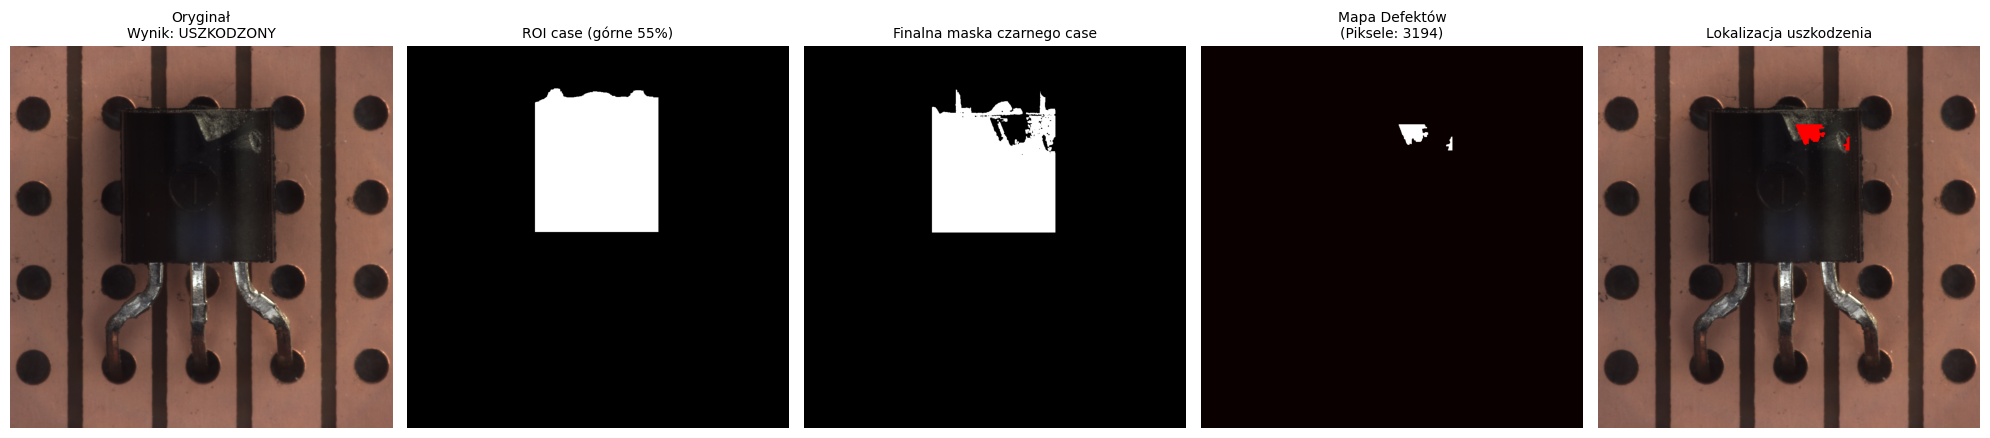

In [57]:
# Załaduj przykładowe zdjęcie (zmień ścieżkę!)
test_img_path = "transistor/test/damaged_case/000.png"

if os.path.exists(test_img_path):
    img = cv2.cvtColor(cv2.imread(test_img_path), cv2.COLOR_BGR2RGB)

    is_def, defect_map, case_region_mask, analysis_case_mask = detect_damaged_case_fixed(img, REFERENCE_MASK)

    # --- Wyświetlanie ---
    plt.figure(figsize=(20, 6))

    plt.subplot(1, 5, 1)
    plt.imshow(img)
    plt.title(f"Oryginał\nWynik: {'USZKODZONY' if is_def else 'OK'}")
    plt.axis('off')

    plt.subplot(1, 5, 2)
    plt.imshow(case_region_mask, cmap='gray')
    plt.title("ROI case (górne 55%)")
    plt.axis('off')

    plt.subplot(1, 5, 3)
    plt.imshow(analysis_case_mask, cmap='gray')
    plt.title("Finalna maska czarnego case")
    plt.axis('off')

    plt.subplot(1, 5, 4)
    plt.imshow(defect_map, cmap='hot')
    plt.title(f"Mapa Defektów\n(Piksele: {np.count_nonzero(defect_map)})")
    plt.axis('off')

    # Nakładka błędu na oryginał
    overlay = img.copy()
    overlay[defect_map > 0] = [255, 0, 0]  # Czerwony kolor błędu
    plt.subplot(1, 5, 5)
    plt.imshow(overlay)
    plt.title("Lokalizacja uszkodzenia")
    plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Brak pliku testowego.")

## Batch test i metryki (good vs damaged_case)
Liczymy metryki binarne i pokazujemy probki TP/TN/FP/FN z overlay mapy defektu.

In [68]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()
TEST_ROOT = PROJECT_ROOT / "transistor" / "test"

def iter_class_files(class_name):
    folder = TEST_ROOT / class_name
    return sorted(folder.glob("*.png"))

def evaluate_damaged_case_dataset(good_limit=None, damaged_limit=None):
    rows = []

    for class_name, limit in [("good", good_limit), ("damaged_case", damaged_limit)]:
        files = iter_class_files(class_name)
        if limit is not None:
            files = files[:limit]

        for p in files:
            img_rgb = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
            pred, defect_map, case_roi, analysis_case = detect_damaged_case_fixed(img_rgb, REFERENCE_MASK)

            rows.append({
                "class_name": class_name,
                "file_name": p.name,
                "path": p,
                "gt": class_name == "damaged_case",
                "pred": bool(pred),
                "defect_pixels": int(np.count_nonzero(defect_map)),
                "defect_map": defect_map,
                "case_roi": case_roi,
                "analysis_case": analysis_case,
            })

    return rows

def summarize_binary_metrics(rows, verbose=True):
    tp = sum(1 for r in rows if r["gt"] and r["pred"])
    tn = sum(1 for r in rows if (not r["gt"]) and (not r["pred"]))
    fp = sum(1 for r in rows if (not r["gt"]) and r["pred"])
    fn = sum(1 for r in rows if r["gt"] and (not r["pred"]))

    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-9)
    accuracy = (tp + tn) / max(len(rows), 1)

    metrics = {
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "accuracy": accuracy,
    }

    if verbose:
        print(f"TP={tp} TN={tn} FP={fp} FN={fn}")
        print(
            f"precision={precision:.3f} recall={recall:.3f} "
            f"f1={f1:.3f} accuracy={accuracy:.3f}"
        )

    return metrics

rows_eval = evaluate_damaged_case_dataset()
metrics_eval = summarize_binary_metrics(rows_eval, verbose=True)

TP=7 TN=47 FP=3 FN=2
precision=0.700 recall=0.778 f1=0.737 accuracy=0.915


Metryki koncowe:
TP=7 TN=47 FP=3 FN=2
precision=0.700 recall=0.778 f1=0.737 accuracy=0.915

=== TP ===


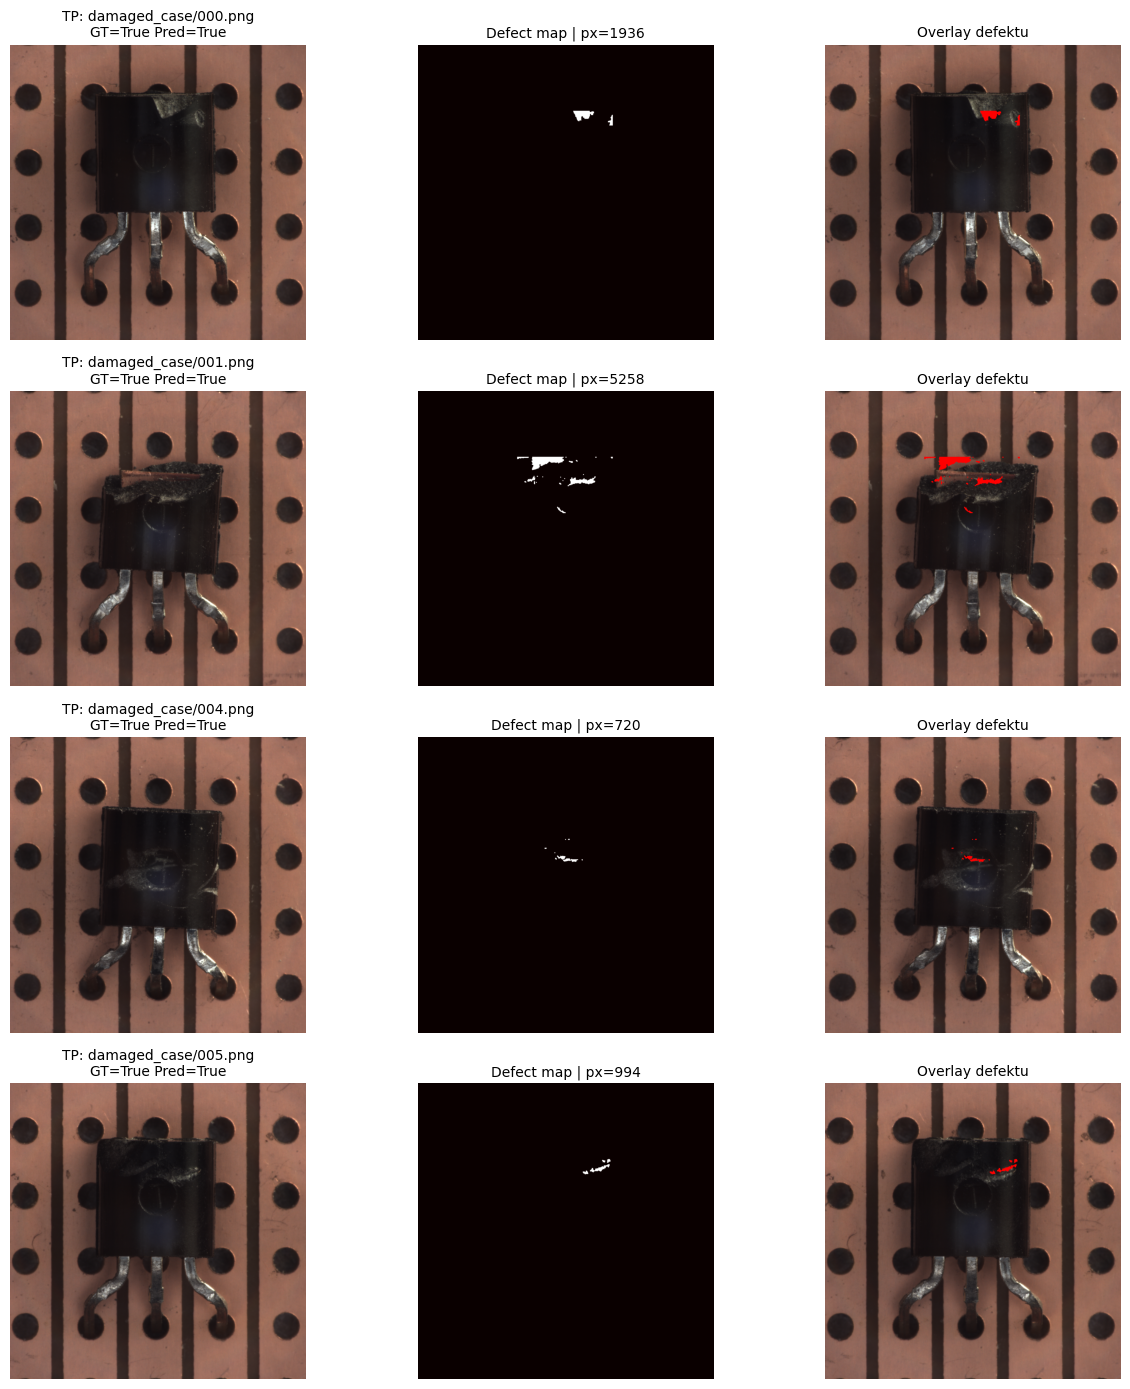


=== TN ===


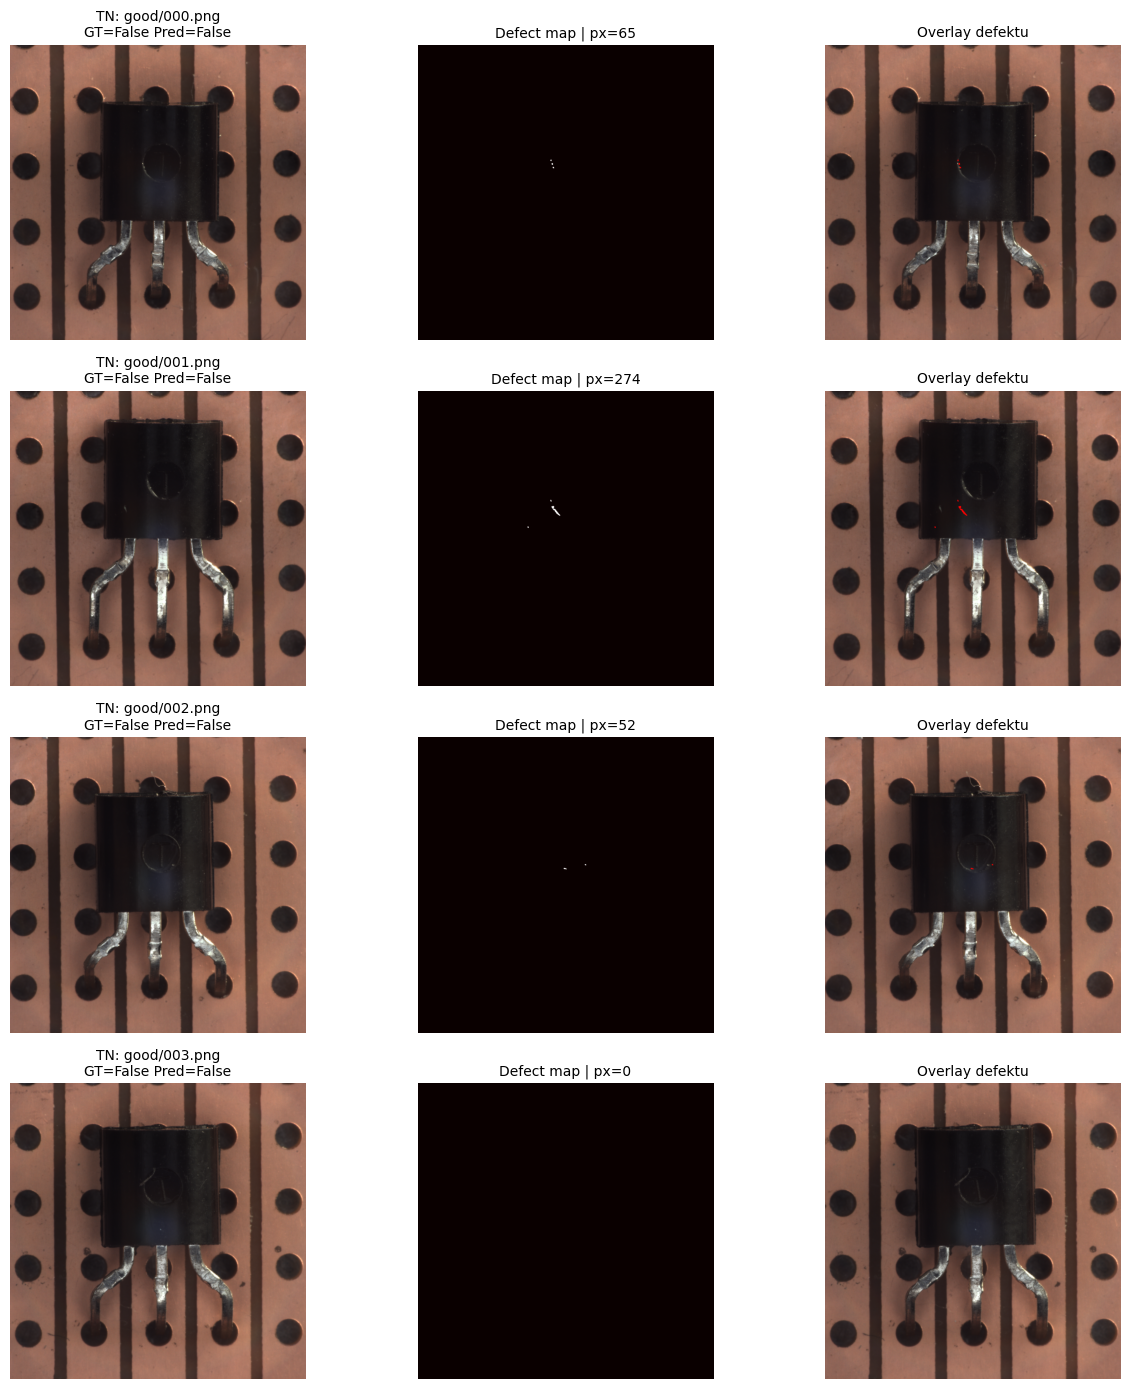


=== FP ===


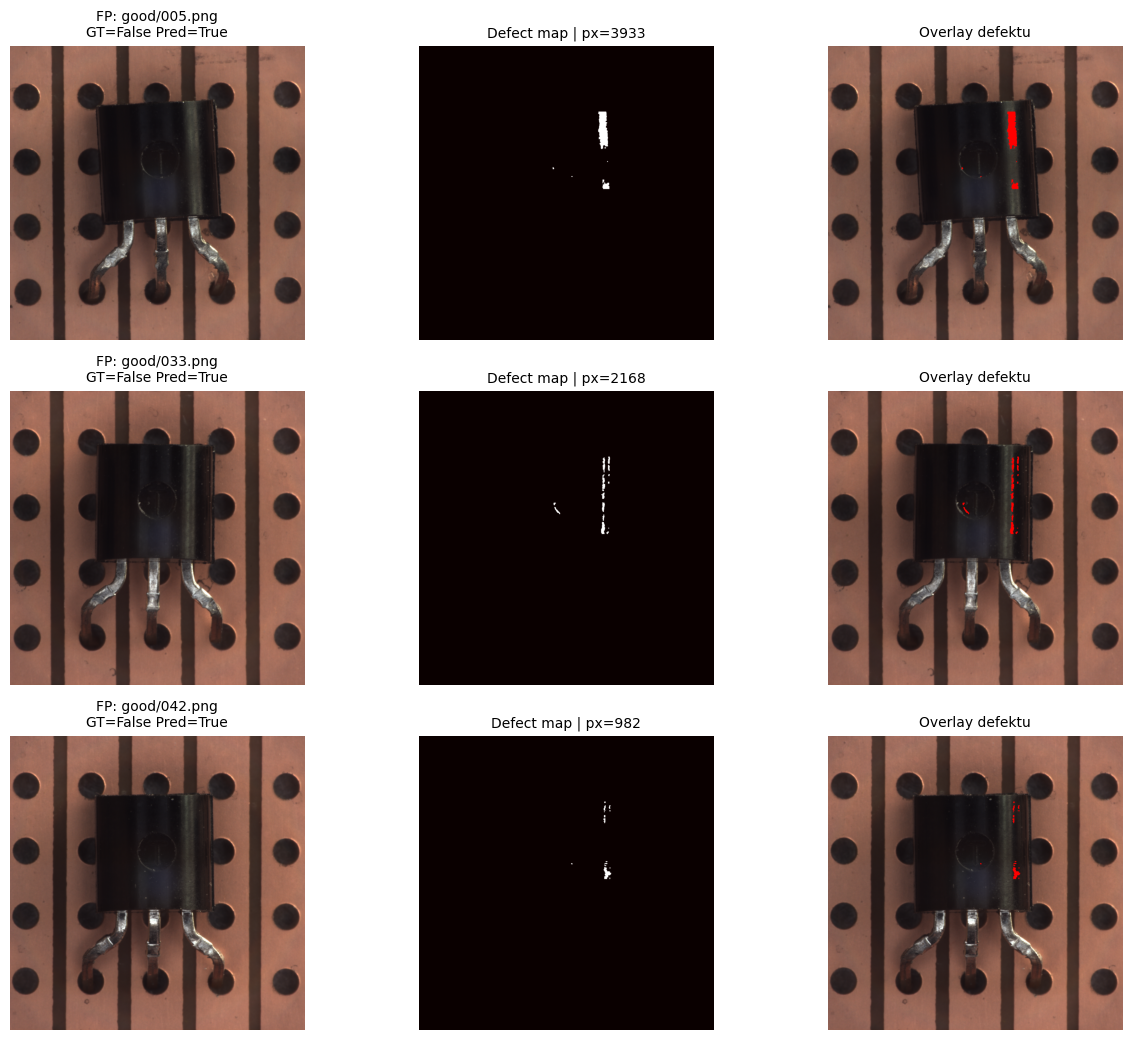


=== FN ===


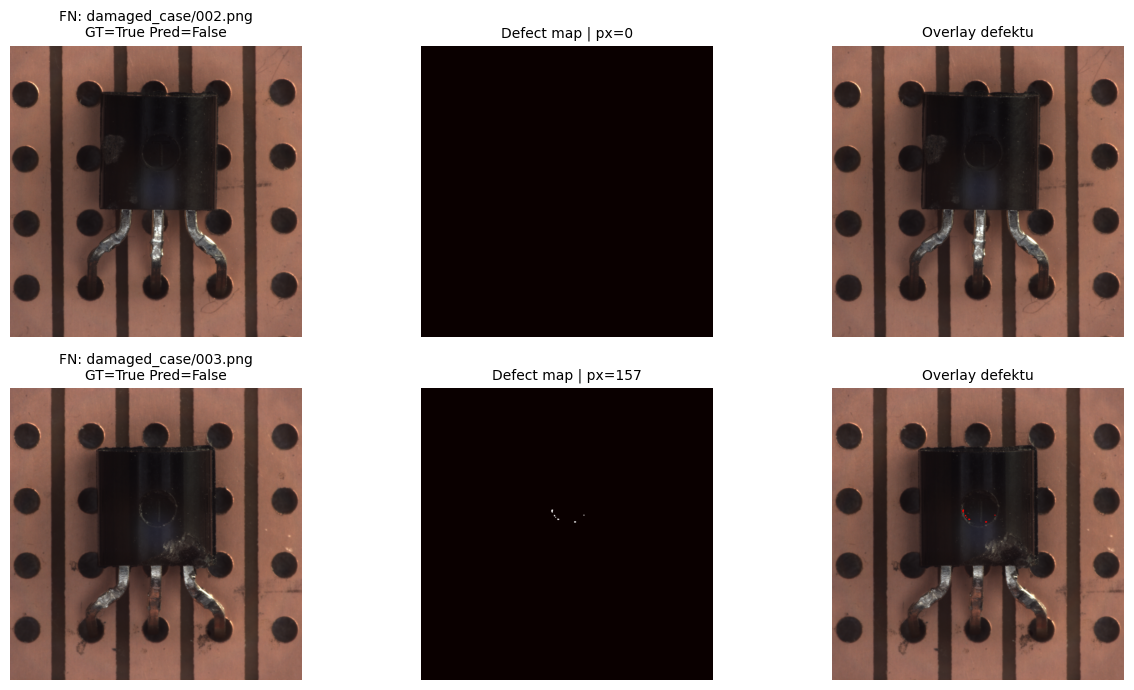

In [69]:
def split_confusion_groups(rows):
    groups = {
        "TP": [r for r in rows if r["gt"] and r["pred"]],
        "TN": [r for r in rows if (not r["gt"]) and (not r["pred"])],
        "FP": [r for r in rows if (not r["gt"]) and r["pred"]],
        "FN": [r for r in rows if r["gt"] and (not r["pred"])],
    }
    return groups

def visualize_group_samples(rows, group_name, max_items=6):
    groups = split_confusion_groups(rows)
    subset = groups[group_name][:max_items]

    if not subset:
        print(f"Brak probek dla grupy {group_name}")
        return

    cols = 3
    n = len(subset)
    fig, axes = plt.subplots(n, cols, figsize=(13, 3.5 * n))
    if n == 1:
        axes = np.array([axes])

    for i, r in enumerate(subset):
        img_rgb = cv2.cvtColor(cv2.imread(str(r["path"])), cv2.COLOR_BGR2RGB)
        pred, defect_map, case_roi, analysis_case = detect_damaged_case_fixed(img_rgb, REFERENCE_MASK)

        overlay = img_rgb.copy()
        overlay[defect_map > 0] = [255, 0, 0]

        axes[i, 0].imshow(img_rgb)
        axes[i, 0].set_title(
            f"{group_name}: {r['class_name']}/{r['file_name']}\n"
            f"GT={r['gt']} Pred={pred}"
        )
        axes[i, 0].axis("off")

        axes[i, 1].imshow(defect_map, cmap="hot")
        axes[i, 1].set_title(f"Defect map | px={np.count_nonzero(defect_map)}")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title("Overlay defektu")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()

# Pokaz metryki i podglad obrazow
print("Metryki koncowe:")
_ = summarize_binary_metrics(rows_eval, verbose=True)

for group in ["TP", "TN", "FP", "FN"]:
    print(f"\n=== {group} ===")
    visualize_group_samples(rows_eval, group_name=group, max_items=4)

In [60]:
# Sweep parametrow z priorytetem: minimalne false positive
from itertools import product

def evaluate_with_params(dark_thr, bright_thr, min_area, top_ignore, erosion_it):
    global DARK_CASE_THRESHOLD, BRIGHTNESS_THRESHOLD, MIN_DAMAGE_AREA, TOP_IGNORE_RATIO, SAFE_EROSION_ITERATIONS

    old = (
        DARK_CASE_THRESHOLD,
        BRIGHTNESS_THRESHOLD,
        MIN_DAMAGE_AREA,
        TOP_IGNORE_RATIO,
        SAFE_EROSION_ITERATIONS,
    )

    DARK_CASE_THRESHOLD = int(dark_thr)
    BRIGHTNESS_THRESHOLD = int(bright_thr)
    MIN_DAMAGE_AREA = int(min_area)
    TOP_IGNORE_RATIO = float(top_ignore)
    SAFE_EROSION_ITERATIONS = int(erosion_it)

    rows = evaluate_damaged_case_dataset()
    m = summarize_binary_metrics(rows, verbose=False)

    # Przywroc stare wartosci globalne
    (
        DARK_CASE_THRESHOLD,
        BRIGHTNESS_THRESHOLD,
        MIN_DAMAGE_AREA,
        TOP_IGNORE_RATIO,
        SAFE_EROSION_ITERATIONS,
    ) = old

    return m

dark_space = [70, 75, 80, 85]
bright_space = [110, 115, 120, 125, 130]
min_area_space = [140, 160, 180, 200, 230, 260]
top_ignore_space = [0.25, 0.30, 0.35]
erosion_space = [1, 2]

results = []
for dark_thr, bright_thr, min_area, top_ignore, erosion_it in product(
    dark_space, bright_space, min_area_space, top_ignore_space, erosion_space
):
    m = evaluate_with_params(dark_thr, bright_thr, min_area, top_ignore, erosion_it)
    results.append({
        "dark_thr": dark_thr,
        "bright_thr": bright_thr,
        "min_area": min_area,
        "top_ignore": top_ignore,
        "erosion_it": erosion_it,
        **m,
    })

# Sortowanie zgodnie z priorytetem:
# 1) najmniej FP
# 2) najmniej FN
# 3) najwyzszy precision
# 4) najwyzszy recall
results_sorted = sorted(
    results,
    key=lambda r: (r["fp"], r["fn"], -r["precision"], -r["recall"])
)

print("TOP 12 konfiguracji (priorytet: FP -> FN -> precision -> recall):")
for i, r in enumerate(results_sorted[:12], start=1):
    print(
        f"{i:02d}. FP={r['fp']} FN={r['fn']} TP={r['tp']} TN={r['tn']} "
        f"P={r['precision']:.3f} R={r['recall']:.3f} F1={r['f1']:.3f} | "
        f"dark={r['dark_thr']} bright={r['bright_thr']} minA={r['min_area']} "
        f"topIgnore={r['top_ignore']:.2f} erosion={r['erosion_it']}"
    )

best_fp_profile = results_sorted[0]
best_no_fp = [r for r in results_sorted if r["fp"] == 0]
if best_no_fp:
    best_no_fp = sorted(best_no_fp, key=lambda r: (r["fn"], -r["recall"], -r["precision"]))[0]
    print("\nNajlepsza konfiguracja z FP=0:")
    print(best_no_fp)
else:
    print("\nBrak konfiguracji z FP=0 w tym zakresie.")

print("\nNajlepsza konfiguracja wg rankingu:")
print(best_fp_profile)

TOP 12 konfiguracji (priorytet: FP -> FN -> precision -> recall):
01. FP=4 FN=2 TP=7 TN=46 P=0.636 R=0.778 F1=0.700 | dark=70 bright=110 minA=260 topIgnore=0.25 erosion=1
02. FP=4 FN=2 TP=7 TN=46 P=0.636 R=0.778 F1=0.700 | dark=70 bright=110 minA=260 topIgnore=0.25 erosion=2
03. FP=4 FN=2 TP=7 TN=46 P=0.636 R=0.778 F1=0.700 | dark=70 bright=110 minA=260 topIgnore=0.30 erosion=1
04. FP=4 FN=2 TP=7 TN=46 P=0.636 R=0.778 F1=0.700 | dark=70 bright=110 minA=260 topIgnore=0.30 erosion=2
05. FP=4 FN=2 TP=7 TN=46 P=0.636 R=0.778 F1=0.700 | dark=70 bright=110 minA=260 topIgnore=0.35 erosion=1
06. FP=4 FN=2 TP=7 TN=46 P=0.636 R=0.778 F1=0.700 | dark=70 bright=110 minA=260 topIgnore=0.35 erosion=2
07. FP=4 FN=2 TP=7 TN=46 P=0.636 R=0.778 F1=0.700 | dark=70 bright=115 minA=260 topIgnore=0.25 erosion=1
08. FP=4 FN=2 TP=7 TN=46 P=0.636 R=0.778 F1=0.700 | dark=70 bright=115 minA=260 topIgnore=0.25 erosion=2
09. FP=4 FN=2 TP=7 TN=46 P=0.636 R=0.778 F1=0.700 | dark=70 bright=115 minA=260 topIgnore=0.30

In [65]:
# Dodatkowy mini-sweep: szybki i konserwatywny (malo FP, ale pilnujemy F1)
SAMPLE_GOOD = 15
SAMPLE_DAMAGED = 15

def evaluate_with_params_fast(dark_thr, bright_thr, min_area, top_ignore, erosion_it):
    global DARK_CASE_THRESHOLD, BRIGHTNESS_THRESHOLD, MIN_DAMAGE_AREA, TOP_IGNORE_RATIO, SAFE_EROSION_ITERATIONS

    old = (
        DARK_CASE_THRESHOLD,
        BRIGHTNESS_THRESHOLD,
        MIN_DAMAGE_AREA,
        TOP_IGNORE_RATIO,
        SAFE_EROSION_ITERATIONS,
    )

    DARK_CASE_THRESHOLD = int(dark_thr)
    BRIGHTNESS_THRESHOLD = int(bright_thr)
    MIN_DAMAGE_AREA = int(min_area)
    TOP_IGNORE_RATIO = float(top_ignore)
    SAFE_EROSION_ITERATIONS = int(erosion_it)

    # Szybki ranking na probce
    rows = evaluate_damaged_case_dataset(good_limit=SAMPLE_GOOD, damaged_limit=SAMPLE_DAMAGED)
    m = summarize_binary_metrics(rows, verbose=False)

    (
        DARK_CASE_THRESHOLD,
        BRIGHTNESS_THRESHOLD,
        MIN_DAMAGE_AREA,
        TOP_IGNORE_RATIO,
        SAFE_EROSION_ITERATIONS,
    ) = old

    return m

strict_dark_space = [65, 75]
strict_bright_space = [130, 145]
strict_min_area_space = [320, 520]
strict_top_ignore_space = [0.30, 0.40]
strict_erosion_space = [1]

strict_results = []
for dark_thr, bright_thr, min_area, top_ignore, erosion_it in product(
    strict_dark_space, strict_bright_space, strict_min_area_space, strict_top_ignore_space, strict_erosion_space
):
    m = evaluate_with_params_fast(dark_thr, bright_thr, min_area, top_ignore, erosion_it)
    strict_results.append({
        "dark_thr": dark_thr,
        "bright_thr": bright_thr,
        "min_area": min_area,
        "top_ignore": top_ignore,
        "erosion_it": erosion_it,
        **m,
    })

# Priorytet: 1) minimalne FP, 2) najwyzsze F1, 3) najmniej FN
strict_sorted = sorted(
    strict_results,
    key=lambda r: (r["fp"], -r["f1"], r["fn"], -r["precision"], -r["recall"])
 )

print(f"Sprawdzone kombinacje: {len(strict_results)} (na probce {SAMPLE_GOOD}+{SAMPLE_DAMAGED})")
print("TOP 8 (profil szybki, konserwatywny):")
for i, r in enumerate(strict_sorted[:8], start=1):
    print(
        f"{i:02d}. FP={r['fp']} FN={r['fn']} TP={r['tp']} TN={r['tn']} "
        f"P={r['precision']:.3f} R={r['recall']:.3f} F1={r['f1']:.3f} | "
        f"dark={r['dark_thr']} bright={r['bright_thr']} minA={r['min_area']} "
        f"topIgnore={r['top_ignore']:.2f} erosion={r['erosion_it']}"
    )

best_cfg = strict_sorted[0]
print("\nWybrana konfiguracja (FP-first + F1):")
print(best_cfg)

# Ustaw najlepsze parametry jako aktywne
DARK_CASE_THRESHOLD = int(best_cfg["dark_thr"])
BRIGHTNESS_THRESHOLD = int(best_cfg["bright_thr"])
MIN_DAMAGE_AREA = int(best_cfg["min_area"])
TOP_IGNORE_RATIO = float(best_cfg["top_ignore"])
SAFE_EROSION_ITERATIONS = int(best_cfg["erosion_it"])

print("\nAktywne parametry po mini-sweep:")
print(
    {
        "DARK_CASE_THRESHOLD": DARK_CASE_THRESHOLD,
        "BRIGHTNESS_THRESHOLD": BRIGHTNESS_THRESHOLD,
        "MIN_DAMAGE_AREA": MIN_DAMAGE_AREA,
        "TOP_IGNORE_RATIO": TOP_IGNORE_RATIO,
        "SAFE_EROSION_ITERATIONS": SAFE_EROSION_ITERATIONS,
    }
)

# Pelna walidacja tylko dla zwyciezcy i raport false positive (klasy + pliki)
rows_best = evaluate_damaged_case_dataset()
metrics_best = summarize_binary_metrics(rows_best, verbose=True)

fp_rows = [r for r in rows_best if (not r["gt"]) and r["pred"]]
print(f"\nFalse Positive count: {len(fp_rows)}")
if fp_rows:
    fp_classes = sorted(set(r["class_name"] for r in fp_rows))
    print(f"Klasy z FP: {fp_classes}")
    print("Pliki FP:")
    for r in fp_rows:
        print(f"  - {r['class_name']}/{r['file_name']} (defect_pixels={r['defect_pixels']})")
else:
    print("Brak false positive dla tej konfiguracji.")

Sprawdzone kombinacje: 16 (na probce 15+15)
TOP 8 (profil szybki, konserwatywny):
01. FP=1 FN=2 TP=7 TN=14 P=0.875 R=0.778 F1=0.824 | dark=65 bright=130 minA=320 topIgnore=0.30 erosion=1
02. FP=1 FN=2 TP=7 TN=14 P=0.875 R=0.778 F1=0.824 | dark=65 bright=145 minA=320 topIgnore=0.30 erosion=1
03. FP=1 FN=2 TP=7 TN=14 P=0.875 R=0.778 F1=0.824 | dark=75 bright=130 minA=320 topIgnore=0.30 erosion=1
04. FP=1 FN=2 TP=7 TN=14 P=0.875 R=0.778 F1=0.824 | dark=75 bright=145 minA=320 topIgnore=0.30 erosion=1
05. FP=1 FN=3 TP=6 TN=14 P=0.857 R=0.667 F1=0.750 | dark=65 bright=130 minA=320 topIgnore=0.40 erosion=1
06. FP=1 FN=3 TP=6 TN=14 P=0.857 R=0.667 F1=0.750 | dark=65 bright=145 minA=320 topIgnore=0.40 erosion=1
07. FP=1 FN=3 TP=6 TN=14 P=0.857 R=0.667 F1=0.750 | dark=75 bright=130 minA=320 topIgnore=0.40 erosion=1
08. FP=1 FN=3 TP=6 TN=14 P=0.857 R=0.667 F1=0.750 | dark=75 bright=145 minA=320 topIgnore=0.40 erosion=1

Wybrana konfiguracja (FP-first + F1):
{'dark_thr': 65, 'bright_thr': 130, 'mi

In [62]:
# Szybki, celowany sweep (maly zakres, priorytet FP)
quick_dark_space = [60, 70]
quick_bright_space = [120, 135, 150]
quick_min_area_space = [260, 320, 400, 500]
quick_top_ignore_space = [0.30, 0.45]
quick_erosion_space = [1]

quick_results = []
for dark_thr, bright_thr, min_area, top_ignore, erosion_it in product(
    quick_dark_space, quick_bright_space, quick_min_area_space, quick_top_ignore_space, quick_erosion_space
):
    m = evaluate_with_params(dark_thr, bright_thr, min_area, top_ignore, erosion_it)
    quick_results.append({
        "dark_thr": dark_thr,
        "bright_thr": bright_thr,
        "min_area": min_area,
        "top_ignore": top_ignore,
        "erosion_it": erosion_it,
        **m,
    })

quick_sorted = sorted(
    quick_results,
    key=lambda r: (r["fp"], r["fn"], -r["precision"], -r["recall"])
)

print("TOP 10 (szybki sweep):")
for i, r in enumerate(quick_sorted[:10], start=1):
    print(
        f"{i:02d}. FP={r['fp']} FN={r['fn']} TP={r['tp']} TN={r['tn']} "
        f"P={r['precision']:.3f} R={r['recall']:.3f} F1={r['f1']:.3f} | "
        f"dark={r['dark_thr']} bright={r['bright_thr']} minA={r['min_area']} "
        f"topIgnore={r['top_ignore']:.2f} erosion={r['erosion_it']}"
    )

quick_best = quick_sorted[0]
print("\nNajlepsza konfiguracja (szybki sweep):")
print(quick_best)

TOP 10 (szybki sweep):
01. FP=3 FN=2 TP=7 TN=47 P=0.700 R=0.778 F1=0.737 | dark=60 bright=120 minA=320 topIgnore=0.30 erosion=1
02. FP=3 FN=2 TP=7 TN=47 P=0.700 R=0.778 F1=0.737 | dark=60 bright=120 minA=400 topIgnore=0.30 erosion=1
03. FP=3 FN=2 TP=7 TN=47 P=0.700 R=0.778 F1=0.737 | dark=60 bright=135 minA=320 topIgnore=0.30 erosion=1
04. FP=3 FN=2 TP=7 TN=47 P=0.700 R=0.778 F1=0.737 | dark=60 bright=135 minA=400 topIgnore=0.30 erosion=1
05. FP=3 FN=2 TP=7 TN=47 P=0.700 R=0.778 F1=0.737 | dark=60 bright=150 minA=320 topIgnore=0.30 erosion=1
06. FP=3 FN=2 TP=7 TN=47 P=0.700 R=0.778 F1=0.737 | dark=60 bright=150 minA=400 topIgnore=0.30 erosion=1
07. FP=3 FN=2 TP=7 TN=47 P=0.700 R=0.778 F1=0.737 | dark=70 bright=120 minA=320 topIgnore=0.30 erosion=1
08. FP=3 FN=2 TP=7 TN=47 P=0.700 R=0.778 F1=0.737 | dark=70 bright=120 minA=400 topIgnore=0.30 erosion=1
09. FP=3 FN=2 TP=7 TN=47 P=0.700 R=0.778 F1=0.737 | dark=70 bright=135 minA=320 topIgnore=0.30 erosion=1
10. FP=3 FN=2 TP=7 TN=47 P=0.700

In [66]:
# Ultra-konserwatywne kandydaty (rekonesans pod jeszcze mniej FP)
ultra_candidates = [
    (60, 140, 500, 0.30, 1),
    (60, 150, 500, 0.30, 1),
    (60, 160, 500, 0.30, 1),
    (60, 140, 650, 0.30, 1),
    (60, 150, 650, 0.30, 1),
    (60, 160, 650, 0.30, 1),
    (60, 140, 800, 0.30, 1),
    (60, 150, 800, 0.30, 1),
    (60, 160, 800, 0.30, 1),
    (55, 150, 650, 0.35, 1),
    (55, 160, 800, 0.35, 1),
    (70, 160, 800, 0.30, 1),
]

ultra_results = []
for dark_thr, bright_thr, min_area, top_ignore, erosion_it in ultra_candidates:
    m = evaluate_with_params(dark_thr, bright_thr, min_area, top_ignore, erosion_it)
    ultra_results.append({
        "dark_thr": dark_thr,
        "bright_thr": bright_thr,
        "min_area": min_area,
        "top_ignore": top_ignore,
        "erosion_it": erosion_it,
        **m,
    })

ultra_sorted = sorted(
    ultra_results,
    key=lambda r: (r["fp"], r["fn"], -r["precision"], -r["recall"])
)

print("Wyniki ultra-konserwatywnych kandydatow:")
for r in ultra_sorted:
    print(
        f"FP={r['fp']} FN={r['fn']} TP={r['tp']} TN={r['tn']} "
        f"P={r['precision']:.3f} R={r['recall']:.3f} F1={r['f1']:.3f} | "
        f"dark={r['dark_thr']} bright={r['bright_thr']} minA={r['min_area']} "
        f"topIgnore={r['top_ignore']:.2f} erosion={r['erosion_it']}"
    )

Wyniki ultra-konserwatywnych kandydatow:
FP=3 FN=3 TP=6 TN=47 P=0.667 R=0.667 F1=0.667 | dark=60 bright=140 minA=500 topIgnore=0.30 erosion=1
FP=3 FN=3 TP=6 TN=47 P=0.667 R=0.667 F1=0.667 | dark=60 bright=150 minA=500 topIgnore=0.30 erosion=1
FP=3 FN=3 TP=6 TN=47 P=0.667 R=0.667 F1=0.667 | dark=60 bright=160 minA=500 topIgnore=0.30 erosion=1
FP=3 FN=4 TP=5 TN=47 P=0.625 R=0.556 F1=0.588 | dark=60 bright=140 minA=650 topIgnore=0.30 erosion=1
FP=3 FN=4 TP=5 TN=47 P=0.625 R=0.556 F1=0.588 | dark=60 bright=150 minA=650 topIgnore=0.30 erosion=1
FP=3 FN=4 TP=5 TN=47 P=0.625 R=0.556 F1=0.588 | dark=60 bright=160 minA=650 topIgnore=0.30 erosion=1
FP=3 FN=4 TP=5 TN=47 P=0.625 R=0.556 F1=0.588 | dark=55 bright=150 minA=650 topIgnore=0.35 erosion=1
FP=3 FN=5 TP=4 TN=47 P=0.571 R=0.444 F1=0.500 | dark=60 bright=140 minA=800 topIgnore=0.30 erosion=1
FP=3 FN=5 TP=4 TN=47 P=0.571 R=0.444 F1=0.500 | dark=60 bright=150 minA=800 topIgnore=0.30 erosion=1
FP=3 FN=5 TP=4 TN=47 P=0.571 R=0.444 F1=0.500 | da